In [2]:
import numpy as np
import os
from astropy.io import fits 

base_path="../data/2018_08_25" # This notebook is located in the "test" folder, at the same level as the "data" folder.

freq_5=os.path.join(base_path,'test_egress_pwr.fits') # Egression power map from 5.0 to 7.0 mHz with cropped edges
with fits.open(freq_5) as hdul5:
    hdr5=hdul5[0].header
    egression_pwr_5=hdul5[0].data

Here we use the cropped 5–7 mHz egression power map in order to avoid possible edge effects. The retained region is defined by the following pixel limits:
$$y,x_{min}=150$$
$$y,x_{max}=844$$ 
Thus, 150 pixels are excluded from the lower/left edges and 179 pixels from the upper/right edges of the original 1024×1024 image. The resulting valid region has a size of 695×695 pixels.

In [3]:
subregion = egression_pwr_5[150:845, 150:845] #Python does not take the upper limit so we make 845 since we're interested in the square that contains 844

print("Any zero inside?:", np.any(subregion == 0)) #Check if there's a zero value inside the cropped region
print("Number of zeros inside:", np.count_nonzero(subregion == 0))

Any zero inside?: False
Number of zeros inside: 0


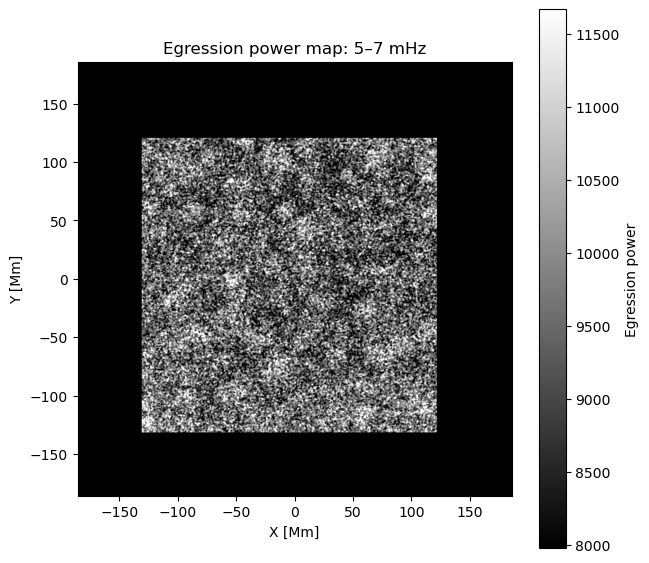

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Spatial sampling, here I assume it is the same as the HMI spatial sample (0.5'' per pixel & 725Km per arcsec)
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel

ny, nx = egression_pwr_5.shape

# Physical dimensions of the map, with the origin at the center of the image

x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample
y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample
extent = [x_min, x_max, y_min, y_max]

plt.figure(figsize=(7, 7))

plt.imshow(
    egression_pwr_5,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(subregion, 5),
    vmax=np.percentile(subregion, 98),
    extent = extent
)

plt.colorbar(label="Egression power")

plt.title("Egression power map: 5–7 mHz")
plt.xlabel("X [Mm]")
plt.ylabel("Y [Mm]")

plt.show()

### Note 
Note: The spatial sampling is provisionally assumed to be 0.3625 Mm pixel
−1
, based on the original HMI sampling. The exact spatial scale after the Postel projection and holography processing still needs to be verified.

## Detecting supergranules through the egression power map at 6mHz
Through the egression power map between frequencies of 5mHz-7mHz it is possible to observe the supergranules as a light bubbles.
The algorithm:
### 1.Convert Zeros at the Edges to NaN Values
### 2. Gaussian Smoothing
### 3. Segmentation by Brightness
### 4.Dilation and Grouping of the Boolean Mask
### 5. Area Discrimination
### 6. Determine the Center of Each Supergranule Candidate
### 7. Compute the Centroid, Area, and Equivalent Radius


Data shape: (1024, 1024)
Valid pixels: 483025
Threshold P65: 9710.8644


/tmp/ipykernel_32124/2347685192.py:124: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean_mask = remove_small_objects(


Detected regions before filtering: 70
Supergranule candidates: 70


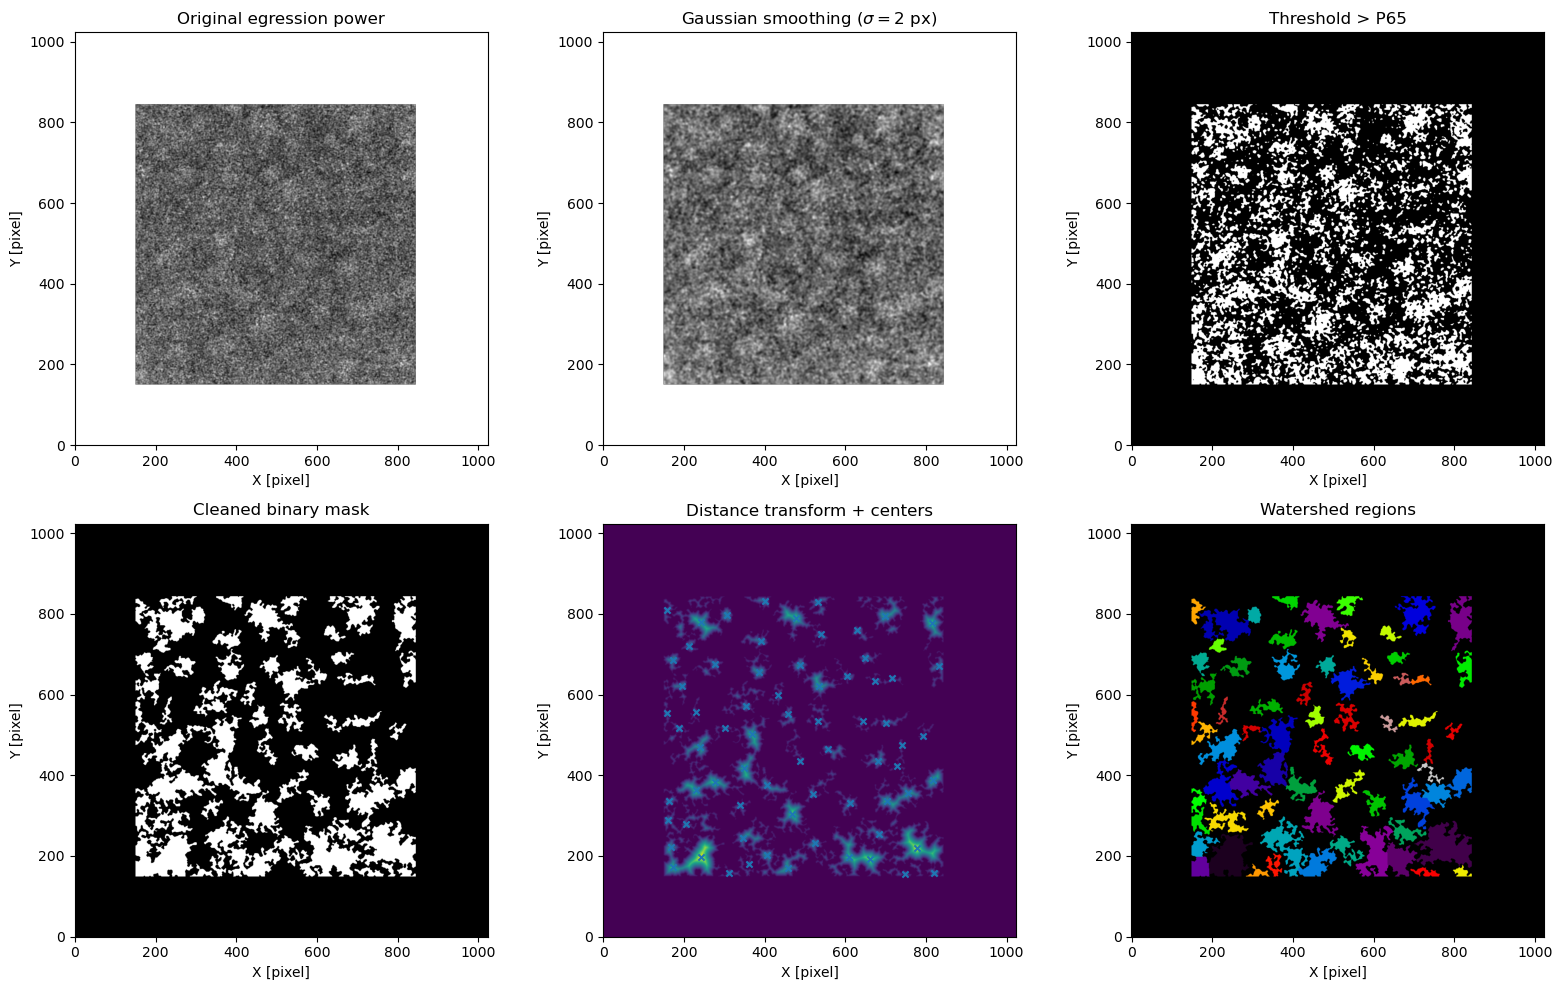

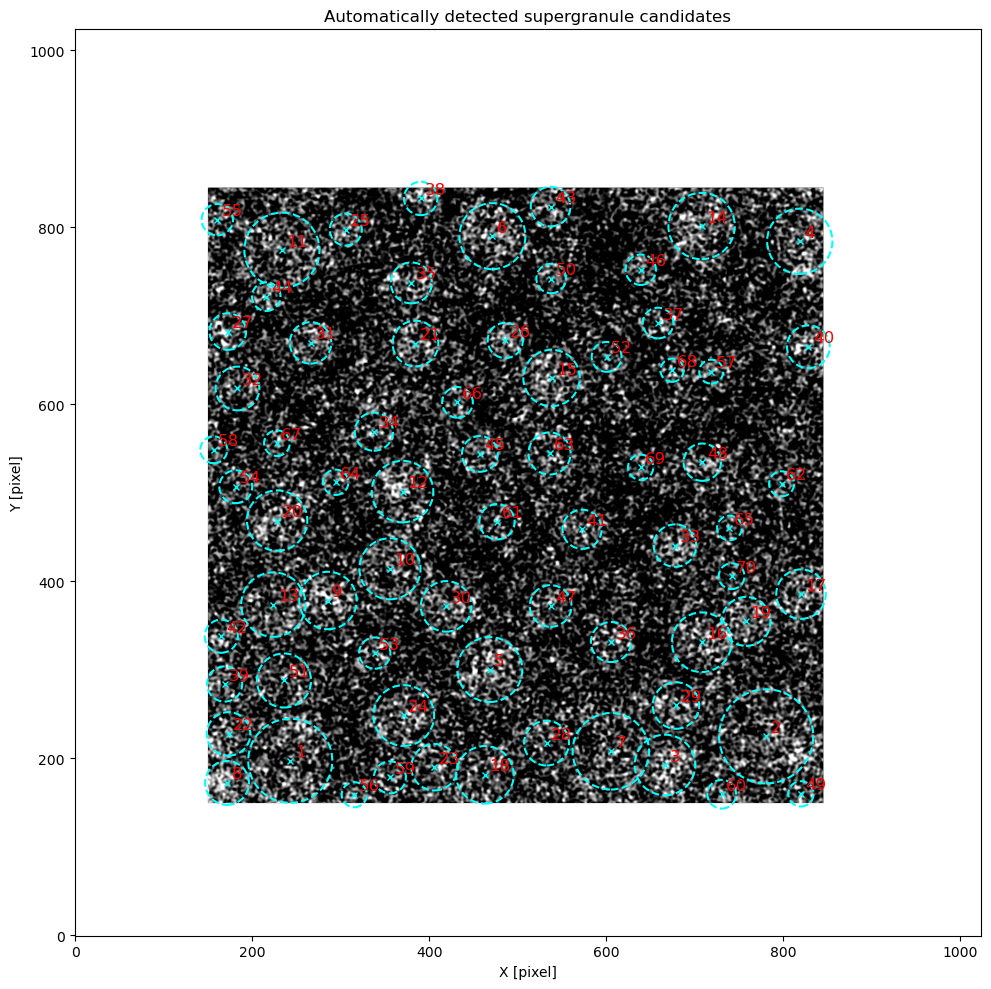

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    gaussian_filter,
    binary_closing,
    binary_fill_holes,
    distance_transform_edt
)

from skimage.morphology import remove_small_objects
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops


# =====================================================
# 1. Original data
# =====================================================

data = egression_pwr_5.astype(float).copy()

# Valid pixels:
# the artificial cropped borders are exactly zero
valid_mask = data != 0

# Replace excluded pixels by NaN without changing
# the original 1024 x 1024 geometry
data[~valid_mask] = np.nan

print("Data shape:", data.shape)
print("Valid pixels:", np.sum(valid_mask))


# =====================================================
# 2. Gaussian smoothing only over valid data
# =====================================================

sigma = 2

# Replace NaNs by zero only for the convolution
values = np.nan_to_num(
    data,
    nan=0.0
)

# Gaussian convolution of the actual values
smooth_values = gaussian_filter(
    values,
    sigma=sigma
)

# Gaussian convolution of a weight map:
# 1 = valid pixel
# 0 = excluded pixel
weights = gaussian_filter(
    valid_mask.astype(float),
    sigma=sigma
)

# Create output initially filled with NaNs
smooth = np.full_like(
    data,
    np.nan
)

# Pixels for which the Gaussian has valid information
good = weights > 0

# Normalized Gaussian smoothing
smooth[good] = (
    smooth_values[good]
    /
    weights[good]
)

# Keep the artificial border excluded
smooth[~valid_mask] = np.nan


# =====================================================
# 3. Threshold bright regions
# =====================================================

percentile_threshold = 65

# NaNs are ignored automatically
threshold = np.nanpercentile(
    smooth,
    percentile_threshold
)

# Bright pixels must:
# 1. be above the threshold
# 2. belong to the valid region
bright_mask = (
    (smooth > threshold)
    &
    valid_mask
)

print(
    f"Threshold P{percentile_threshold}: "
    f"{threshold:.4f}"
)


# =====================================================
# 4. Morphological cleaning
# =====================================================

# Connect nearby bright patches
clean_mask = binary_closing(
    bright_mask,
    iterations=2
)

# Fill holes inside detected regions
clean_mask = binary_fill_holes(
    clean_mask
)

# Remove small connected structures
clean_mask = remove_small_objects(
    clean_mask,
    min_size=500
)

# Make absolutely sure no operation has expanded
# the mask into the excluded border
clean_mask &= valid_mask


# =====================================================
# 5. Distance transform
# =====================================================

distance = distance_transform_edt(
    clean_mask
)


# =====================================================
# 6. Detect candidate supergranule centers
# =====================================================

coords = peak_local_max(
    distance,
    labels=clean_mask,
    min_distance=30
)

markers = np.zeros_like(
    distance,
    dtype=int
)

for i, (y, x) in enumerate(
    coords,
    start=1
):
    markers[y, x] = i


# =====================================================
# 7. Watershed segmentation
# =====================================================

labels = watershed(
    -distance,
    markers,
    mask=clean_mask
)


# =====================================================
# 8. Characterize detected regions
# =====================================================

regions = regionprops(labels)

print(
    f"Detected regions before filtering: "
    f"{len(regions)}"
)

supergranules = []

for region in regions:

    cy, cx = region.centroid
    area = region.area

    # Radius of a circle with the same area
    radius = np.sqrt(
        area / np.pi
    )

    supergranules.append({
        "x": cx,
        "y": cy,
        "area": area,
        "radius": radius
    })

print(
    f"Supergranule candidates: "
    f"{len(supergranules)}"
)


# =====================================================
# 9. Plot processing steps
# =====================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.ravel()


# -----------------------------------------------------
# Original
# -----------------------------------------------------

axes[0].imshow(
    data,
    origin="lower",
    cmap="gray"
)

axes[0].set_title(
    "Original egression power"
)


# -----------------------------------------------------
# Smoothed
# -----------------------------------------------------

axes[1].imshow(
    smooth,
    origin="lower",
    cmap="gray"
)

axes[1].set_title(
    f"Gaussian smoothing "
    rf"($\sigma={sigma}$ px)"
)


# -----------------------------------------------------
# Threshold
# -----------------------------------------------------

axes[2].imshow(
    bright_mask,
    origin="lower",
    cmap="gray"
)

axes[2].set_title(
    f"Threshold > P{percentile_threshold}"
)


# -----------------------------------------------------
# Cleaned mask
# -----------------------------------------------------

axes[3].imshow(
    clean_mask,
    origin="lower",
    cmap="gray"
)

axes[3].set_title(
    "Cleaned binary mask"
)


# -----------------------------------------------------
# Distance transform + centers
# -----------------------------------------------------

axes[4].imshow(
    distance,
    origin="lower",
    cmap="viridis"
)

if len(coords) > 0:
    axes[4].scatter(
        coords[:, 1],
        coords[:, 0],
        s=20,
        marker="x"
    )

axes[4].set_title(
    "Distance transform + centers"
)


# -----------------------------------------------------
# Watershed
# -----------------------------------------------------

axes[5].imshow(
    labels,
    origin="lower",
    cmap="nipy_spectral"
)

axes[5].set_title(
    "Watershed regions"
)


for ax in axes:
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")


plt.tight_layout()
plt.show()


# =====================================================
# 10. Plot circular supergranule masks
# =====================================================

fig, ax = plt.subplots(
    figsize=(10, 10)
)

vmin, vmax = np.nanpercentile(
    data,
    [35, 99.5]
)

ax.imshow(
    data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)


for i, sg in enumerate(
    supergranules,
    start=1
):

    circle = plt.Circle(
        (sg["x"], sg["y"]),
        sg["radius"],
        fill=False,
        linestyle="--",
        linewidth=1.5,
        color="cyan"
    )

    ax.add_patch(circle)

    ax.plot(
        sg["x"],
        sg["y"],
        marker="x",
        markersize=5,
        color="cyan"
    )

    ax.text(
        sg["x"] + 5,
        sg["y"] + 5,
        str(i),
        fontsize=12,
        color="red"
    )


ax.set_title(
    "Automatically detected supergranule candidates"
)

ax.set_xlabel(
    "X [pixel]"
)

ax.set_ylabel(
    "Y [pixel]"
)
plt.savefig('egression_with_circles.png')
plt.tight_layout()
plt.show()

Number of bubbles: 70
Mean radius: 8.91 Mm
Standard deviation: 3.25 Mm
Mean radius ± std: 8.91 ± 3.25 Mm


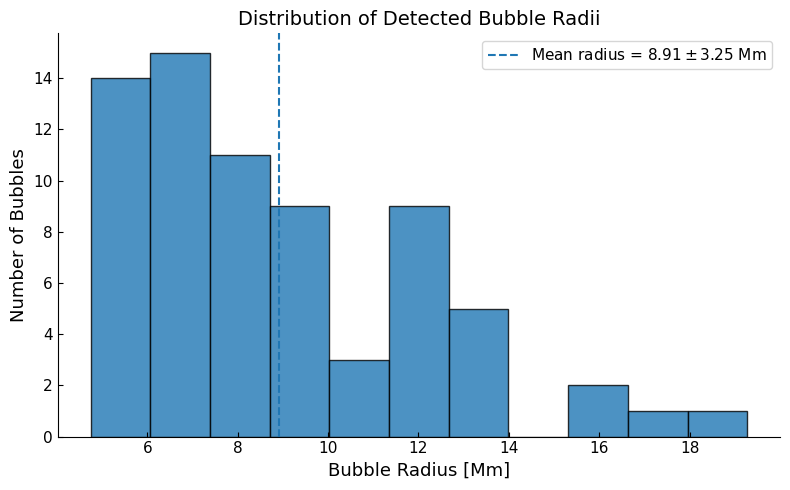

In [6]:
# =====================================================
# Supergranule radius statistics
# =====================================================
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Bubble radii in physical units
# =====================================================

# Extract radii in pixels
radii_px = np.array([
    sg["radius"] for sg in supergranules
])

# Convert radii to Mm
radii_mm = radii_px * spatial_sample

# Basic statistics in Mm
mean_radius_mm = np.mean(radii_mm)
std_radius_mm = np.std(radii_mm)

print(f"Number of bubbles: {len(radii_mm)}")
print(f"Mean radius: {mean_radius_mm:.2f} Mm")
print(f"Standard deviation: {std_radius_mm:.2f} Mm")
print(
    f"Mean radius ± std: "
    f"{mean_radius_mm:.2f} ± {std_radius_mm:.2f} Mm"
)


# =====================================================
# Bubble radius distribution
# =====================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    radii_mm,
    bins=11,
    edgecolor="black",
    alpha=0.8
)

# Mean radius
ax.axvline(
    mean_radius_mm,
    linestyle="--",
    linewidth=1.5,
    label=(
        rf"Mean radius = "
        rf"${mean_radius_mm:.2f} \pm {std_radius_mm:.2f}$ Mm"
    )
)

ax.set_xlabel(
    "Bubble Radius [Mm]",
    fontsize=13
)

ax.set_ylabel(
    "Number of Bubbles",
    fontsize=13
)

ax.set_title(
    "Distribution of Detected Bubble Radii",
    fontsize=14
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    direction="in"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=11
)

fig.tight_layout()

plt.savefig(
    "bubble_radius_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
import numpy as np

centers_x = np.array([sg["x"] for sg in supergranules])
centers_y = np.array([sg["y"] for sg in supergranules])
radii = np.array([sg["radius"] for sg in supergranules])

np.savez(
    "../data/2018_08_25/supergranule_masks_geometry.npz",
    x=centers_x,
    y=centers_y,
    radius=radii
)

## Create Individual Circular Masks

For each detected supergranule, create a Boolean circular mask centered at its centroid, using its equivalent radius. Pixels inside the equivalent circle are assigned True, while pixels outside are assigned False.

In [8]:
# =====================================================
# Create individual masks for ALL detected supergranules
# =====================================================

ny, nx = egression_pwr_5.shape
yy, xx = np.ogrid[:ny, :nx]

individual_masks = {}

for sg_id, sg in enumerate(supergranules, start=1):

    mask = (
        (xx - sg["x"])**2 +
        (yy - sg["y"])**2
        <= sg["radius"]**2
    )

    individual_masks[sg_id] = mask

In [9]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

files = {
    "2.0-3.0 mHz": "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "3.0-4.0 mHz": "egress_pwr_03.0-04.0mHz_z0000km.fits",
    "4.0-5.0 mHz": "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "5.0-6.0 mHz": "egress_pwr_05.0-06.0mHz_z0000km.fits",
    "6.0-7.0 mHz": "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "7.0-8.0 mHz": "egress_pwr_07.0-08.0mHz_z0000km.fits",
    "8.0-9.0 mHz": "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10.0-11.0 mHz": "egress_pwr_10.0-11.0mHz_z0000km.fits",
}
frequencies = list(files.keys())

egression_maps = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    egression_maps.append(data_map)

print("Number of maps:", len(egression_maps))
print("Shape of first map:", egression_maps[0].shape)

Number of maps: 9
Shape of first map: (1024, 1024)


## Bubbles in Other Egression Power Frequency Maps

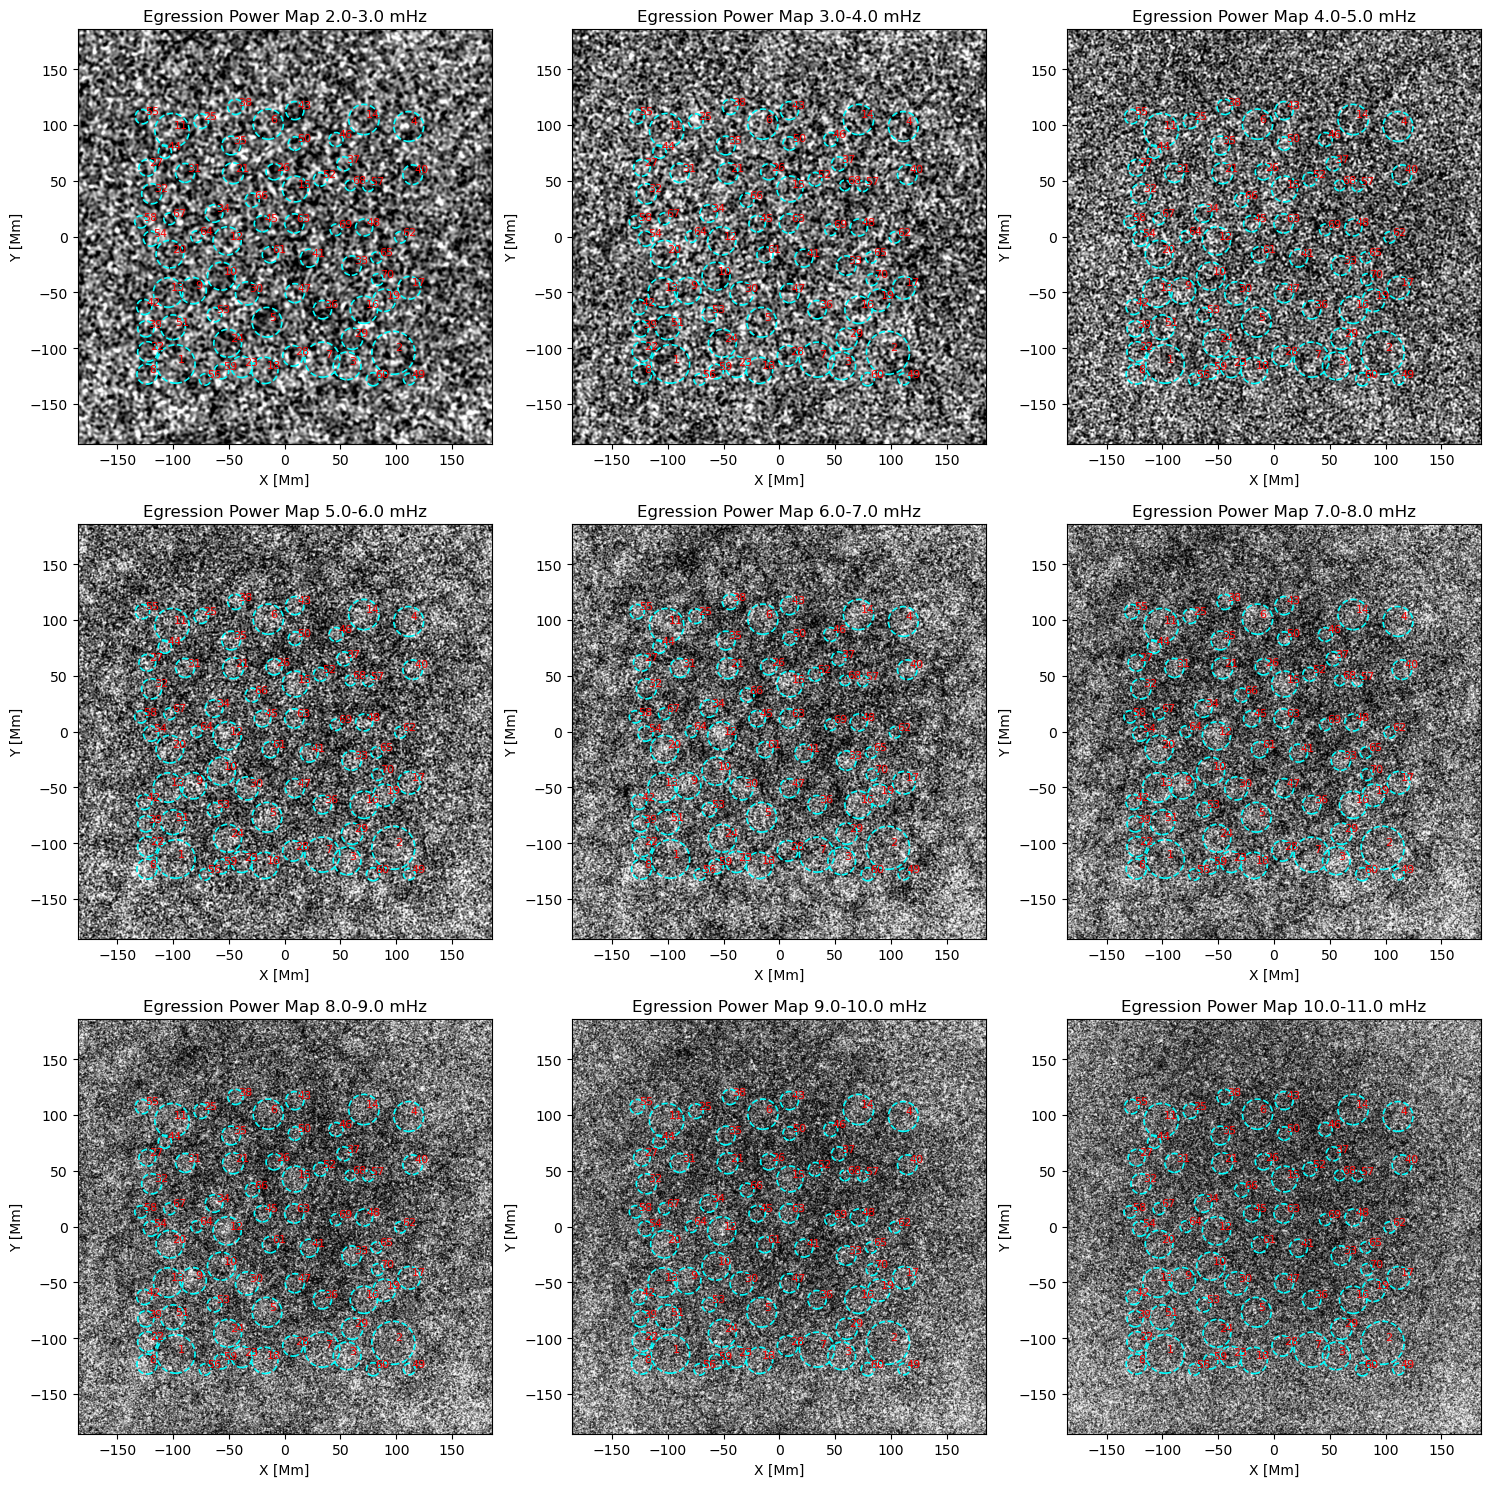

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

axes = axes.ravel()

for ax, data, freq_band in zip(
    axes,
    egression_maps,
    frequencies
):

    vmin, vmax = np.nanpercentile(
        data[data != 0],
        [5, 98]
    )

    ax.imshow(
        data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )

    # Plot all supergranules
    for sg_id, sg in enumerate(supergranules, start=1):

        # Convert from pixels to Mm
        x_mm = (sg["x"] - nx / 2) * spatial_sample
        y_mm = (sg["y"] - ny / 2) * spatial_sample
        r_mm = sg["radius"] * spatial_sample

        circle = plt.Circle(
            (x_mm, y_mm),
            r_mm,
            fill=False,
            linestyle="--",
            linewidth=1.2,
            color="cyan"
        )

        ax.add_patch(circle)

        ax.text(
            x_mm + 2,
            y_mm + 2,
            str(sg_id),
            fontsize=8,
            color="red"
        )

    ax.set_title(f"Egression Power Map {freq_band}")
    ax.set_xlabel("X [Mm]")
    ax.set_ylabel("Y [Mm]")

plt.tight_layout()
plt.show()

## Compute the Mean Egression Power of Each Supergranule in Every Egression Power Map

In [11]:
mean_values_per_map = []
mean_all_supergranules_per_map = []
std_all_valid_values_per_map = []

for data_map in egression_maps:

    # =====================================================
    # Mean value of each individual supergranule
    # =====================================================
    mean_values = []

    for sg_id, mask in individual_masks.items():

        values = data_map[mask] #Values inside the circular mask (supergranule candidate)

        mean_values.append(
            np.nanmean(values) #Compute the mean value inside the SG and ignoring the Nan values
        )

    mean_values = np.array(mean_values) #List to array ;) 

    # Store the array corresponding to this map
    mean_values_per_map.append(mean_values)

    # =====================================================
    # Mean of all supergranule mean values in this map
    # =====================================================
    mean_all_supergranules_per_map.append(
        np.nanmean(mean_values)
    )

    # =====================================================
    # Standard deviation of ALL valid pixels
    # inside the supergranule masks
    # =====================================================
    all_values = []

    for sg_id, mask in individual_masks.items():

        values = data_map[mask]

        all_values.append(values)

    all_values = np.concatenate(all_values)

    std_all_valid_values_per_map.append(
        np.nanstd(all_values)
    )


# Convert global results to NumPy arrays
mean_all_supergranules_per_map = np.array(
    mean_all_supergranules_per_map
)

std_all_valid_values_per_map = np.array(
    std_all_valid_values_per_map
)

print(len(mean_values_per_map[0]))
print(mean_all_supergranules_per_map)
print(std_all_valid_values_per_map)

70
[101565.57   311210.22    84070.94    14574.854    5211.1714   2842.7349
   1457.7174    881.8303    645.7702]
[14346.923    36407.047    10486.346     1822.436      621.47736
   359.72968    183.81705    114.34441     82.055595]


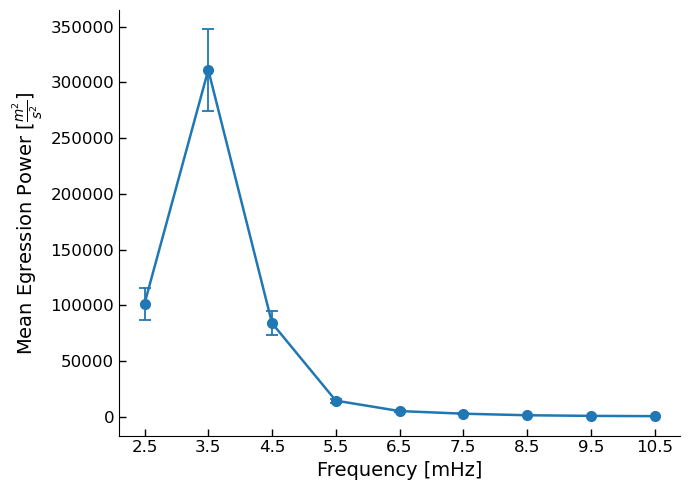

In [12]:
central_frequencies = np.array([
    2.5,
    3.5,
    4.5,
    5.5,
    6.5,
    7.5,
    8.5,
    9.5,
    10.5
])

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    central_frequencies,
    mean_all_supergranules_per_map,
    yerr=std_all_valid_values_per_map,
    fmt='o-',
    markersize=7,
    linewidth=1.8,
    elinewidth=1.3,
    capsize=4,
    capthick=1.3
)

# Axis labels
ax.set_xlabel('Frequency [mHz]', fontsize=14)
ax.set_ylabel(r'Mean Egression Power [$\frac{m^2}{s^2}$]', fontsize=14)

# Ticks
ax.tick_params(
    axis='both',
    which='major',
    labelsize=12,
    direction='in',
    length=5,
    width=1
)

# Axes appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Frequency values shown explicitly
ax.set_xticks(central_frequencies)

fig.tight_layout()
plt.savefig('egress_pwr_vs_freq_65.png')
plt.show()

In [ ]:
# =====================================================
# Spatial coordinates in Mm
# =====================================================

# Postel angular sampling
daxis = 0.0005  # rad / pixel

# Solar radius
rsun = 696.0  # Mm

# Physical spatial scale
spatial_scale = daxis * rsun  # Mm / pixel

# Image dimensions
ny, nx = data.shape

# Projection center in pixel coordinates
x0 = nx / 2
y0 = ny / 2

# Physical extent of the image
extent = [
    -x0 * spatial_scale,
    (nx - x0) * spatial_scale,
    -y0 * spatial_scale,
    (ny - y0) * spatial_scale
]

print(f"Spatial scale: {spatial_scale:.3f} Mm/pixel")
print(f"Projection center: ({x0:.1f}, {y0:.1f}) pixels")
print(f"X range: {extent[0]:.2f} to {extent[1]:.2f} Mm")
print(f"Y range: {extent[2]:.2f} to {extent[3]:.2f} Mm")

In [ ]:
# =====================================================
# Egression power map used for supergranule detection
# 6.0–7.0 mHz
# =====================================================

egression_pwr_6_7 = egression_maps[4].astype(float).copy()

# Artificial cropped borders are exactly zero
valid_mask = egression_pwr_6_7 != 0

egression_pwr_6_7[~valid_mask] = np.nan

print("Shape:", egression_pwr_6_7.shape)

## Problem with the pupil at the edges

In [ ]:
# =====================================================
# Illustrate observational pupils at different
# positions on the 6–7 mHz egression power map
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.patches import Circle, Rectangle


# -----------------------------------------------------
# Select 6–7 mHz egression power map
# -----------------------------------------------------

egression_6_7 = egression_maps[4].astype(float).copy()


# -----------------------------------------------------
# Spatial scale of the Postel projection
# -----------------------------------------------------

rsun = 696.0      # Mm
daxis = 0.0005    # rad / pixel

spatial_scale = daxis * rsun   # Mm / pixel

ny, nx = egression_6_7.shape

x0 = nx / 2
y0 = ny / 2

extent = [
    -x0 * spatial_scale,
    (nx - x0) * spatial_scale,
    -y0 * spatial_scale,
    (ny - y0) * spatial_scale
]


# -----------------------------------------------------
# Pupil geometry
# -----------------------------------------------------

outer_diameter_px = 165
inner_diameter_px = 70

outer_radius_px = outer_diameter_px / 2
inner_radius_px = inner_diameter_px / 2

outer_radius_mm = outer_radius_px * spatial_scale
inner_radius_mm = inner_radius_px * spatial_scale


# -----------------------------------------------------
# Pupil centers in pixel coordinates
# -----------------------------------------------------

pupil_centers_px = [
    (20, 18),      # close to corner
    (195, 195),    # close to cropped-region limit
    (512, 512)     # image center
]


# -----------------------------------------------------
# Plot
# -----------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))

# Use only non-zero values to define the display range
valid_values = egression_6_7[egression_6_7 != 0]

vmin, vmax = np.percentile(
    valid_values,
    [5, 98.5]
)

im = ax.imshow(
    egression_6_7,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    extent=extent
)


# -----------------------------------------------------
# Draw pupil pairs
# -----------------------------------------------------

for i, (cx_px, cy_px) in enumerate(
    pupil_centers_px,
    start=1
):

    cx_mm = (cx_px - x0) * spatial_scale
    cy_mm = (cy_px - y0) * spatial_scale

    outer_circle = Circle(
        (cx_mm, cy_mm),
        outer_radius_mm,
        fill=False,
        linestyle="--",
        linewidth=2,
        color="cyan"
    )

    inner_circle = Circle(
        (cx_mm, cy_mm),
        inner_radius_mm,
        fill=False,
        linestyle="-",
        linewidth=2,
        color="red"
    )

    ax.add_patch(outer_circle)
    ax.add_patch(inner_circle)

    ax.plot(
        cx_mm,
        cy_mm,
        marker="x",
        markersize=7,
        color="yellow"
    )

    ax.text(
        cx_mm + 3,
        cy_mm + 3,
        f"Pupil {i}",
        fontsize=10,
        color="yellow"
    )
# -----------------------------------------------------
# Region used for supergranule detection
# -----------------------------------------------------

crop_min_px = 150
crop_max_px = 844

# Convert boundaries from pixels to Mm
crop_x_min_mm = (crop_min_px - x0) * spatial_scale
crop_x_max_mm = (crop_max_px - x0) * spatial_scale

crop_y_min_mm = (crop_min_px - y0) * spatial_scale
crop_y_max_mm = (crop_max_px - y0) * spatial_scale
# Rectangle dimensions
crop_width_mm = crop_x_max_mm - crop_x_min_mm
crop_height_mm = crop_y_max_mm - crop_y_min_mm

crop_rectangle = Rectangle(
    (crop_x_min_mm, crop_y_min_mm),
    crop_width_mm,
    crop_height_mm,
    fill=False,
    linestyle="--",
    linewidth=2,
    edgecolor="lime",
    label="Analyzed Region"
)

ax.add_patch(crop_rectangle)

# Preserve original map boundaries
ax.set_xlim(
    extent[0],
    extent[1]
)

ax.set_ylim(
    extent[2],
    extent[3]
)

# Labels
ax.set_title(
    "Observational Pupils at Different Positions",
    fontsize=15
)

ax.set_xlabel("X [Mm]",fontsize=18)
ax.set_ylabel("Y [Mm]",fontsize=18)

ax.tick_params(
    axis="both",
    labelsize=18
)

# Legend
ax.legend(
    loc="upper right",
    frameon=True
)

# Colorbar
fig.colorbar(
    im,
    ax=ax,
    label=r"Egression Power [$m^2\,s^{-2}$]"
)

fig.tight_layout()

# Save BEFORE show
plt.savefig(
    "Pupil_at_Different_Positions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =====================================================
# Mosaic of egression power maps
# 2 rows x 3 columns
# =====================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


# -----------------------------------------------------
# Base path
# -----------------------------------------------------

base_path = "../data/2018_08_25"


# -----------------------------------------------------
# Egression power maps
# -----------------------------------------------------

files_mosaic = {
    "2–3 mHz":  "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "4–5 mHz":  "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "6–7 mHz":  "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "8–9 mHz":  "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9–10 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10–11 mHz":"egress_pwr_10.0-11.0mHz_z0000km.fits",
}


# -----------------------------------------------------
# Load maps
# -----------------------------------------------------

maps = []

for frequency, filename in files_mosaic.items():

    path = os.path.join(
        base_path,
        filename
    )

    with fits.open(path) as hdul:
        map_data = hdul[0].data.astype(float).copy()

    maps.append(
        (frequency, map_data)
    )


# -----------------------------------------------------
# Spatial scale
# -----------------------------------------------------

rsun = 696.0      # Mm
daxis = 0.0005    # rad / pixel

spatial_scale = daxis * rsun

ny, nx = maps[0][1].shape

x0 = nx / 2
y0 = ny / 2

extent = [
    -x0 * spatial_scale,
    (nx - x0) * spatial_scale,
    -y0 * spatial_scale,
    (ny - y0) * spatial_scale
]


# -----------------------------------------------------
# Create 2 x 3 mosaic
# -----------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()


# -----------------------------------------------------
# Plot each frequency
# -----------------------------------------------------

for ax, (frequency, map_data) in zip(
    axes,
    maps
):

    # Exclude artificial zeros ONLY when calculating
    # the display limits
    valid_values = map_data[
        np.isfinite(map_data) &
        (map_data != 0)
    ]

    vmin, vmax = np.percentile(
        valid_values,
        [5, 98.5]
    )

    im = ax.imshow(
        map_data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )

    ax.set_title(
        frequency,
        fontsize=15
    )


# -----------------------------------------------------
# Axis labels
# -----------------------------------------------------

# Y labels only on left column
axes[0].set_ylabel("Y [Mm]", fontsize=18)
axes[3].set_ylabel("Y [Mm]", fontsize=18)

# X labels only on bottom row
axes[3].set_xlabel("X [Mm]", fontsize=18)
axes[4].set_xlabel("X [Mm]", fontsize=18)
axes[5].set_xlabel("X [Mm]", fontsize=18)


# -----------------------------------------------------
# General formatting
# -----------------------------------------------------

for ax in axes:

    ax.set_xlim(
        extent[0],
        extent[1]
    )

    ax.set_ylim(
        extent[2],
        extent[3]
    )

    ax.tick_params(
        labelsize=15
    )


# -----------------------------------------------------
# Spacing
# -----------------------------------------------------

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.95,
    wspace=0.08,
    hspace=0.15
)


# -----------------------------------------------------
# Save
# -----------------------------------------------------

fig.savefig(
    "Egression_Power_Frequency_Mosaic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Exploring Bubble-like Structures in the Other Egression Power Maps